# HAM10000 Dataset Exploration
## Skin Lesion Classification - Deep Learning Project

**Dataset:** HAM10000 - Human Against Machine with 10000 training images  
**Objective:** Exploratory Data Analysis for 7-class skin lesion classification  
**Classes:** akiec, bcc, bkl, df, mel, nv, vasc

## 1. Import Libraries

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().absolute().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

from src.data.preprocessing import SkinLesionPreprocessor

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

## 2. Load Dataset

In [ ]:
# Paths
DATA_DIR = Path('D:/dl_data/data')
METADATA_FILE = DATA_DIR / 'HAM10000_metadata.csv'
IMAGE_DIR_1 = DATA_DIR / 'HAM10000_images_part_1'
IMAGE_DIR_2 = DATA_DIR / 'HAM10000_images_part_2'

# Load metadata
df = pd.read_csv(METADATA_FILE)

print(f"Dataset shape: {df.shape}")
print(f"Total samples: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
df.head(10)

## 3. Dataset Information

In [ ]:
print("📊 Dataset Info:")
print("="*60)
df.info()
print("\n📈 Statistical Summary:")
print("="*60)
df.describe()

## 4. Class Distribution Analysis

In [ ]:
# Class distribution
class_counts = df['dx'].value_counts()

# Class names mapping
CLASS_NAMES = {
    'akiec': 'Actinic Keratoses and Intraepithelial Carcinoma',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis-like Lesions',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Skin Lesions'
}

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA15E', '#BC6C25']
class_counts.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Class Distribution', fontsize=16, fontweight='bold')
ax1.set_xlabel('Diagnosis', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(class_counts):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
ax2.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Class Proportions', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Class Distribution:")
print("="*70)
for dx, count in class_counts.items():
    pct = (count / len(df) * 100)
    full_name = CLASS_NAMES.get(dx, dx)
    print(f"{dx:6s} ({full_name:50s}): {count:5d} ({pct:5.2f}%)")
print("="*70)

## 5. Class Imbalance Analysis

In [ ]:
# Calculate imbalance ratio
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print(f"\n⚖️ Class Imbalance Analysis:")
print("="*60)
print(f"Most frequent class: {class_counts.idxmax()} ({max_count} samples)")
print(f"Least frequent class: {class_counts.idxmin()} ({min_count} samples)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
print("\n⚠️ High class imbalance detected!")
print("   → Solution: Use class weights during training")
print("   → Solution: Apply data augmentation for minority classes")

## 6. Compute Class Weights

In [ ]:
# Use preprocessor to compute class weights
preprocessor = SkinLesionPreprocessor('D:/dl_data/data')
class_weights = preprocessor.compute_class_weights('D:/dl_data/data/HAM10000_metadata.csv')

print("\n⚖️ Computed Class Weights:")
print("="*60)
for i, weight in class_weights.items():
    class_name = list(CLASS_NAMES.keys())[i]
    print(f"Class {i} ({class_name}): {weight:.4f}")
print("\n✅ These weights will be used in CrossEntropyLoss during training")

## 7. Age Distribution

In [ ]:
# Age distribution
if 'age' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Overall age distribution
    df['age'].dropna().hist(bins=30, ax=axes[0], color='#4ECDC4', edgecolor='black')
    axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Age', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Age by diagnosis
    df.boxplot(column='age', by='dx', ax=axes[1])
    axes[1].set_title('Age Distribution by Diagnosis', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Diagnosis', fontsize=12)
    axes[1].set_ylabel('Age', fontsize=12)
    plt.suptitle('')
    
    plt.tight_layout()
    plt.savefig('../plots/age_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n👥 Age Statistics:")
    print("="*60)
    print(f"Mean age: {df['age'].mean():.1f} years")
    print(f"Median age: {df['age'].median():.1f} years")
    print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")

## 8. Gender Distribution

In [ ]:
# Gender distribution
if 'sex' in df.columns:
    gender_counts = df['sex'].value_counts()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Overall gender distribution
    gender_counts.plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4'])
    ax1.set_title('Gender Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Gender', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.set_xticklabels(['Male', 'Female'], rotation=0)
    
    # Gender by diagnosis
    pd.crosstab(df['dx'], df['sex']).plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'])
    ax2.set_title('Gender Distribution by Diagnosis', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Diagnosis', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.legend(['Male', 'Female'])
    
    plt.tight_layout()
    plt.savefig('../plots/gender_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

## 9. Localization Distribution

In [ ]:
# Localization distribution
if 'localization' in df.columns:
    loc_counts = df['localization'].value_counts().head(10)
    
    plt.figure(figsize=(14, 6))
    loc_counts.plot(kind='barh', color='#45B7D1')
    plt.title('Top 10 Lesion Locations', fontsize=14, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Location', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../plots/localization_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. Sample Images from Each Class

In [ ]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (dx, name) in enumerate(CLASS_NAMES.items()):
    # Get a random sample from this class
    sample = df[df['dx'] == dx].sample(1).iloc[0]
    image_id = sample['image_id']
    
    # Try both image directories
    image_path = IMAGE_DIR_1 / f"{image_id}.jpg"
    if not image_path.exists():
        image_path = IMAGE_DIR_2 / f"{image_id}.jpg"
    
    if image_path.exists():
        img = Image.open(image_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{name}\n({dx})", fontweight='bold', fontsize=11)
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        axes[idx].set_title(f"{name}\n({dx})", fontweight='bold')
        axes[idx].axis('off')

axes[-1].axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../plots/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Image Size Analysis

In [ ]:
# Sample 100 images to analyze size
sample_images = df.sample(min(100, len(df)))
widths = []
heights = []

for _, row in sample_images.iterrows():
    image_id = row['image_id']
    image_path = IMAGE_DIR_1 / f"{image_id}.jpg"
    if not image_path.exists():
        image_path = IMAGE_DIR_2 / f"{image_id}.jpg"
    
    if image_path.exists():
        img = Image.open(image_path)
        widths.append(img.width)
        heights.append(img.height)

if widths and heights:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    ax1.scatter(widths, heights, alpha=0.5, color='#4ECDC4')
    ax1.set_title('Image Dimensions (Sample)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Width (pixels)', fontsize=12)
    ax1.set_ylabel('Height (pixels)', fontsize=12)
    ax1.grid(alpha=0.3)
    
    ax2.hist([widths, heights], label=['Width', 'Height'], bins=20, alpha=0.7)
    ax2.set_title('Dimension Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Pixels', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📐 Image Size Statistics (from {len(widths)} samples):")
    print("="*60)
    print(f"Width  - Min: {min(widths):4d}px, Max: {max(widths):4d}px, Avg: {np.mean(widths):.0f}px")
    print(f"Height - Min: {min(heights):4d}px, Max: {max(heights):4d}px, Avg: {np.mean(heights):.0f}px")
    print(f"\n✅ Images will be resized to 224x224 for training")

## 12. Key Findings & Recommendations

In [ ]:
print("\n" + "="*70)
print("KEY FINDINGS & RECOMMENDATIONS")
print("="*70)

print("\n📊 Dataset Characteristics:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Number of classes: {df['dx'].nunique()}")
print(f"  • Most common class: {class_counts.idxmax()} ({class_counts.max():,} samples)")
print(f"  • Least common class: {class_counts.idxmin()} ({class_counts.min()} samples)")

print("\n⚠️ Challenges Identified:")
print(f"  • Severe class imbalance ({imbalance_ratio:.1f}:1 ratio)")
print("  • Melanocytic nevi (nv) dominates with 67% of samples")
print("  • Dermatofibroma (df) and vascular (vasc) are rare (<2% each)")

print("\n✅ Recommended Solutions:")
print("  1. Use class weights in loss function (already implemented)")
print("  2. Apply heavy data augmentation (rotation, flip, color jitter)")
print("  3. Use stratified train/val/test splits")
print("  4. Monitor per-class metrics (not just overall accuracy)")
print("  5. Consider oversampling minority classes")

print("\n🎯 Training Strategy:")
print("  • Architecture: EfficientNet-B3 (pretrained on ImageNet)")
print("  • Input size: 224×224×3")
print("  • Batch size: 32")
print("  • Learning rate: 1e-4 with cosine annealing")
print("  • Optimizer: AdamW with weight decay")
print("  • Loss: CrossEntropyLoss with class weights")
print("  • Regularization: Dropout (0.3) + data augmentation")

print("\n" + "="*70)
print("✅ Data exploration complete!")
print("📁 Plots saved to: ../plots/")
print("🚀 Ready to start training!")
print("="*70)

## 1. Import Libraries

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().absolute().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Dataset

**Note:** Download HAM10000 dataset from Kaggle:
```bash
kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
```

Update paths below to match your data location.

In [3]:
#Paths
DATA_DIR = Path('D:/dl_data/data')
METADATA_FILE = DATA_DIR / 'HAM10000_metadata.csv'
IMAGE_DIR_1 = DATA_DIR / 'HAM10000_images_part_1'
IMAGE_DIR_2 = DATA_DIR / 'HAM10000_images_part_2'

# Load metadata
df = pd.read_csv(METADATA_FILE)

print(f"Dataset shape: {df.shape}")
print(f"Total samples: {len(df)}")
df.head()

Dataset shape: (10015, 7)
Total samples: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


## 3. Dataset Overview

In [5]:
# Basic info
print("DATASET INFORMATION")
print(df.info())
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print(df.describe(include='all'))

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None

SUMMARY STATISTICS
          lesion_id      image_id     dx dx_type          age    sex  \
count         10015         10015  10015   10015  9958.000000  10015   
unique         7470         10015      7       4          NaN      3   
top     HAM_0003789  ISIC_0027419     nv   histo          NaN   male   
freq              6             1   6705    5340          NaN   5406   
mean            NaN           NaN    NaN     N

In [7]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Total missing: 57


## 4. Class Distribution Analysis

In [9]:
# Class distribution
class_counts = df['dx'].value_counts()
class_percentages = (class_counts / len(df) * 100).round(2)

print("CLASS DISTRIBUTION")
for dx, count in class_counts.items():
    pct = class_percentages[dx]
    print(f"{dx:6s}: {count:5d} samples ({pct:5.2f}%)")

# Class descriptions
CLASS_DESCRIPTIONS = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'mel': 'Melanoma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions'
}

CLASS DISTRIBUTION
nv    :  6705 samples (66.95%)
mel   :  1113 samples (11.11%)
bkl   :  1099 samples (10.97%)
bcc   :   514 samples ( 5.13%)
akiec :   327 samples ( 3.27%)
vasc  :   142 samples ( 1.42%)
df    :   115 samples ( 1.15%)


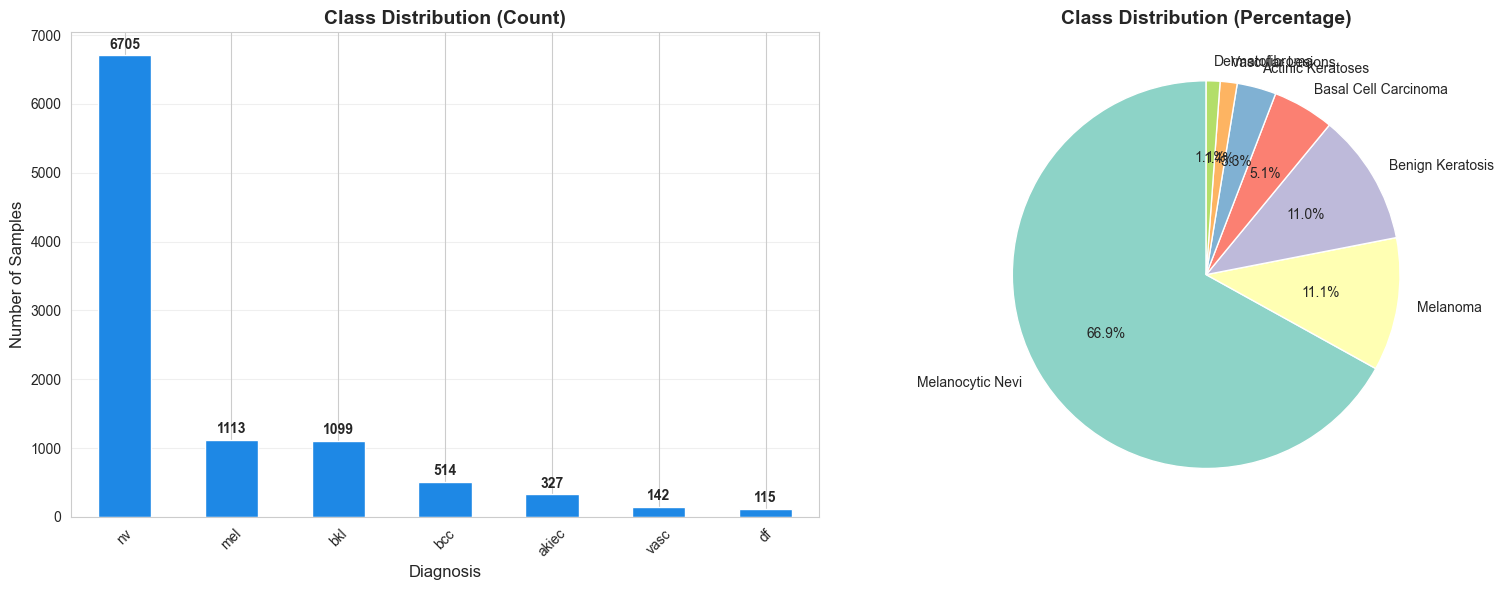


 Class Imbalance Detected:
Most common class (nv): 6705 samples (66.95%)
Least common class (df): 115 samples (1.15%)
Imbalance ratio: 58.3:1


In [11]:
# Visualize class distribution - Bar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot with counts
class_counts.plot(kind='bar', ax=ax1, color='#1E88E5')
ax1.set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Diagnosis', fontsize=12)
ax1.set_ylabel('Number of Samples', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(class_counts):
    ax1.text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart with percentages
colors = plt.cm.Set3(range(len(class_counts)))
ax2.pie(class_counts, labels=[CLASS_DESCRIPTIONS[dx] for dx in class_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Class Imbalance Detected:")
print(f"Most common class (nv): {class_counts['nv']} samples ({class_percentages['nv']}%)")
print(f"Least common class (df): {class_counts['df']} samples ({class_percentages['df']}%)")
print(f"Imbalance ratio: {class_counts['nv'] / class_counts['df']:.1f}:1")

## 5. Demographic Analysis

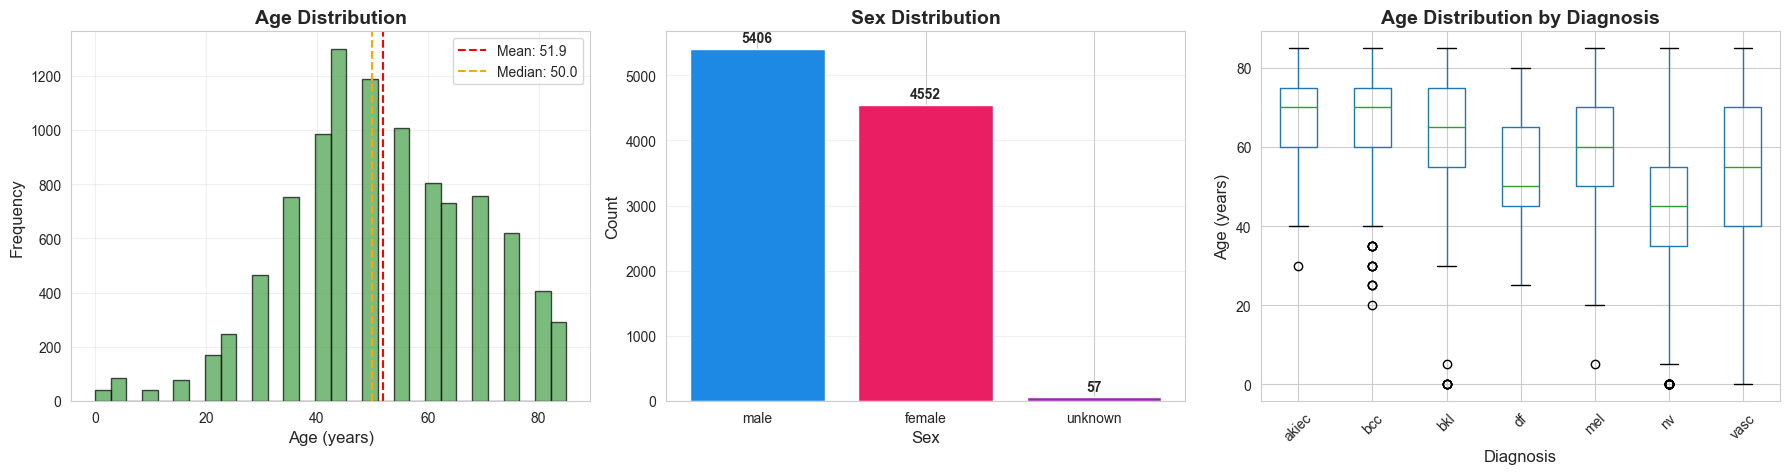


📊 Age Statistics:
count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


In [13]:
# Age distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age histogram
axes[0].hist(df['age'].dropna(), bins=30, color='#43A047', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', label=f'Median: {df["age"].median():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sex distribution
sex_counts = df['sex'].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values, color=['#1E88E5', '#E91E63', '#9C27B0'])
axes[1].set_title('Sex Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Age by diagnosis boxplot
df.boxplot(column='age', by='dx', ax=axes[2])
axes[2].set_title('Age Distribution by Diagnosis', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Diagnosis', fontsize=12)
axes[2].set_ylabel('Age (years)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print("\n📊 Age Statistics:")
print(df['age'].describe())

## 6. Localization Analysis

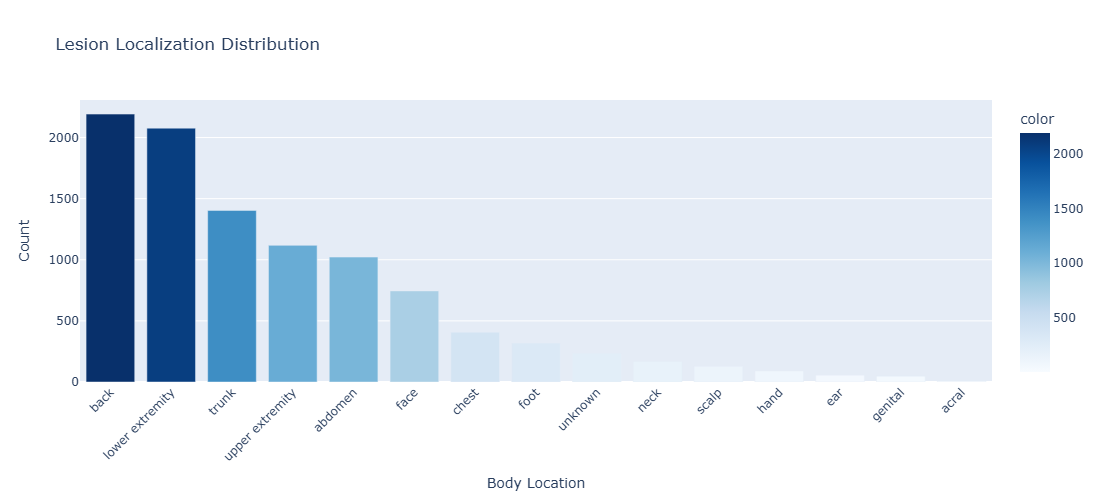


 Top 5 Localizations:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
Name: count, dtype: int64


In [15]:
# Localization distribution
loc_counts = df['localization'].value_counts()

fig = px.bar(
    x=loc_counts.index,
    y=loc_counts.values,
    title='Lesion Localization Distribution',
    labels={'x': 'Body Location', 'y': 'Count'},
    color=loc_counts.values,
    color_continuous_scale='Blues'
)
fig.update_layout(
    xaxis_tickangle=-45,
    height=500,
    showlegend=False
)
fig.show()

print("\n Top 5 Localizations:")
print(loc_counts.head())

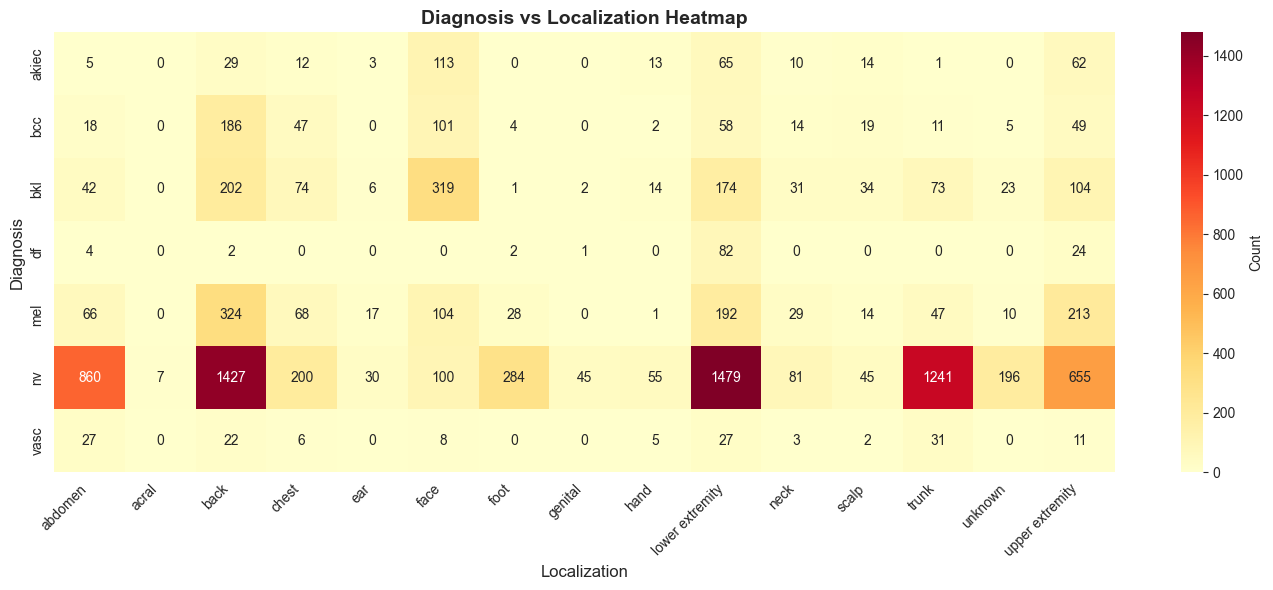

In [17]:
# Cross-tabulation: Diagnosis vs Localization
ct = pd.crosstab(df['dx'], df['localization'])

plt.figure(figsize=(14, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.title('Diagnosis vs Localization Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Localization', fontsize=12)
plt.ylabel('Diagnosis', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Sample Images Visualization

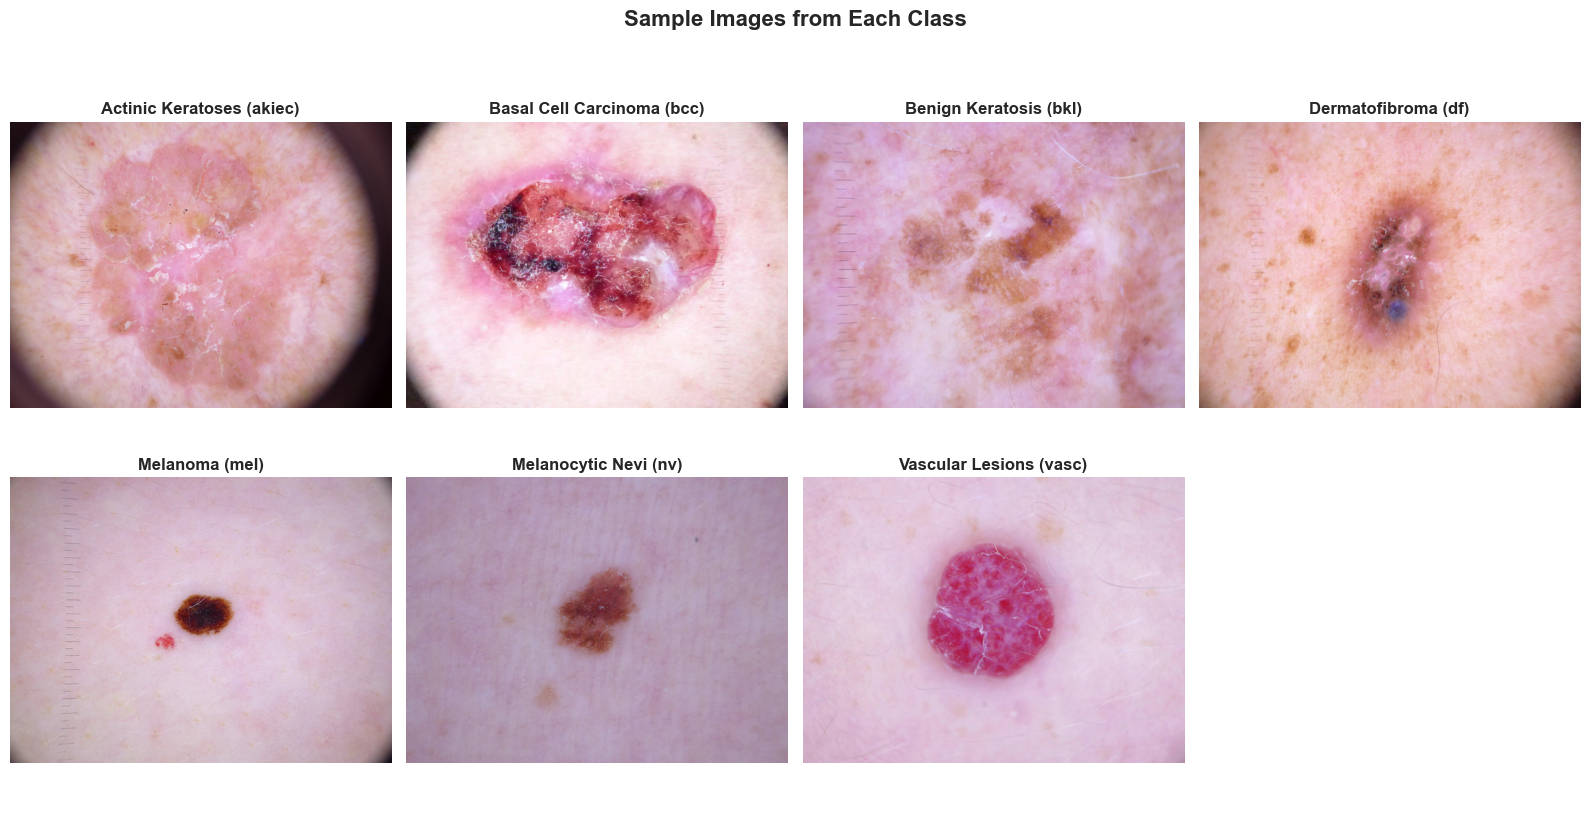

In [19]:
# Display sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (dx, desc) in enumerate(CLASS_DESCRIPTIONS.items()):
    # Get first sample from each class
    sample = df[df['dx'] == dx].iloc[0]
    image_id = sample['image_id']
    
    # Try to find image
    image_path = IMAGE_DIR_1 / f"{image_id}.jpg"
    if not image_path.exists():
        image_path = IMAGE_DIR_2 / f"{image_id}.jpg"
    
    if image_path.exists():
        img = Image.open(image_path)
        axes[idx].imshow(img)
        axes[idx].set_title(f"{desc} ({dx})", fontweight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        axes[idx].set_title(f"{desc} ({dx})", fontweight='bold')
        axes[idx].axis('off')

# Hide last empty subplot
axes[-1].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Data Quality Assessment

Unique lesions: 7470
Total images: 10015
Duplicate lesions: 1956

Lesions with most images:
lesion_id
HAM_0003789    6
HAM_0000835    6
HAM_0005263    6
HAM_0001863    6
HAM_0007427    5
HAM_0007343    5
HAM_0000893    5
HAM_0007367    5
HAM_0002364    5
HAM_0003602    4
Name: count, dtype: int64


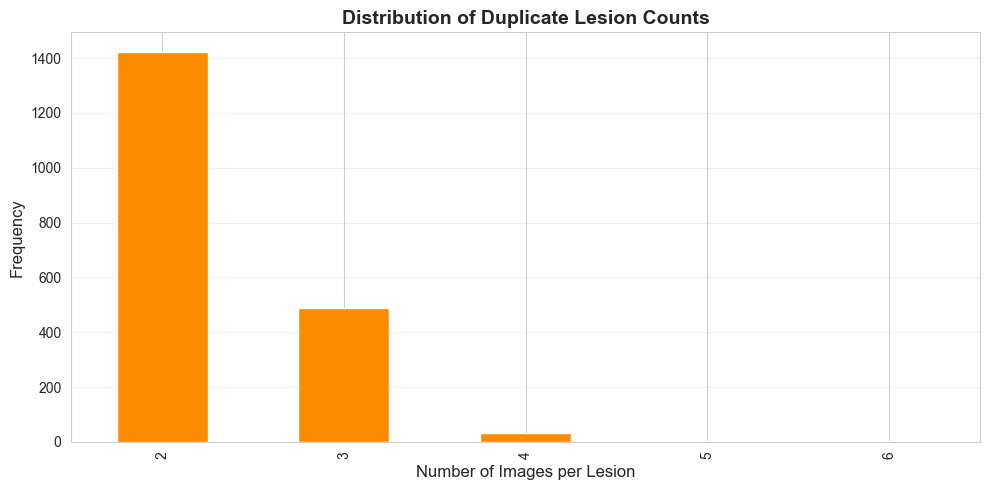

In [21]:
# Check for duplicate lesions
duplicate_lesions = df['lesion_id'].value_counts()
duplicates = duplicate_lesions[duplicate_lesions > 1]

print(f"Unique lesions: {df['lesion_id'].nunique()}")
print(f"Total images: {len(df)}")
print(f"Duplicate lesions: {len(duplicates)}")
print(f"\nLesions with most images:")
print(duplicates.head(10))

# Visualize duplicates
plt.figure(figsize=(10, 5))
duplicate_lesions[duplicate_lesions > 1].value_counts().plot(kind='bar', color='#FB8C00')
plt.title('Distribution of Duplicate Lesion Counts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Images per Lesion', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Key Insights and Recommendations

### Key Findings:

1. **Severe Class Imbalance**
   - Melanocytic nevi (nv) dominates with ~67% of samples
   - Dermatofibroma (df) is extremely rare with ~1% of samples
   - **Recommendation:** Use class weights, data augmentation, and focal loss

2. **Duplicate Lesions**
   - Multiple images exist for same lesions
   - Risk of data leakage between train/test sets
   - **Recommendation:** Split by lesion_id, not image_id

3. **Demographic Patterns**
   - Age varies significantly by diagnosis type
   - Some diagnoses show strong age/sex correlations
   - **Recommendation:** Could use metadata as auxiliary features

4. **Localization Diversity**
   - Lesions distributed across various body locations
   - Some locations more common than others
   - **Recommendation:** Consider location-specific augmentations

5. **Data Quality**
   - Missing age values in some samples
   - All images appear to be present and valid
   - **Recommendation:** Handle missing values during preprocessing